In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, GORDO
import warnings
warnings.simplefilter('ignore', FutureWarning)


# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
    matplotlib.rcParams['axes.labelsize'] = fontsize
    matplotlib.rcParams['legend.fontsize'] = fontsize
    matplotlib.rcParams['figure.titlesize'] = fontsize


torch.Size([10, 11])


In [15]:
%%time
from inference_utils import get_prior
prior = get_prior('GORDO')
with open('posterior_singles.pkl', 'rb') as f:
    posterior = pickle.load(f)

epsilon = -10
Xs = torch.tensor(X)
op = CollectivePosterior(prior, Xs, posterior, 1, epsilon, n_eval=10000)

print(op.get_log_C())
print(op.log_prob(th))
est = op.sample(1000).mean(0)
est

<timed exec>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


tensor(10.8234)
tensor([-3.4129])


Rejection Sampling: 1338it [00:00, 2731.11it/s]                         

CPU times: user 1min 36s, sys: 1.12 s, total: 1min 37s
Wall time: 2.22 s


tensor([-7.6272,  8.3210, -1.6067])

In [10]:
import torch, math

# number of MC samples
N = 200_000

# sample from the prior
theta = op.prior.sample((N,))   # assuming op is your CollectivePosterior

# compute log q_coll(theta) with your fixed log_prob
log_q = op.log_prob(theta)      # shape (N,)

# estimate ∫ q_coll(θ) dθ via importance sampling with θ ~ prior:
# E_p[q_coll(θ)/p(θ)] = 1 if normalized
logp = op.prior.log_prob(theta).reshape(-1)
log_w = log_q - logp

# log-mean-exp
log_est = torch.logsumexp(log_w, dim=0) - math.log(N)
est = log_est.exp()

print("Estimated integral of q_coll over parameter space:", est.item())


Estimated integral of q_coll over parameter space: 1.0099376440048218


In [18]:
change_font(20)
est = op.sample(10000).mean(0)
est, th

Rejection Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/GORDO/../collective_posterior.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 10242it [00:05, 1981.07it/s]                          


(tensor([-5.8526,  7.5572, -3.3759]), tensor([-6.0000, 10.0000, -3.7000]))

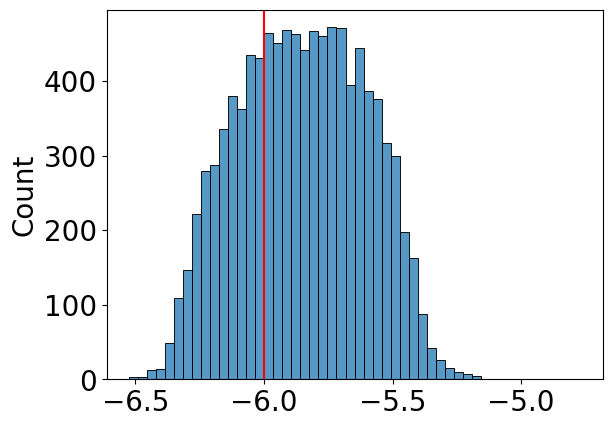

In [19]:
histplot(op.samples[:,0])
plt.axvline(th[0], color='red')

Text(0, 0.5, '')

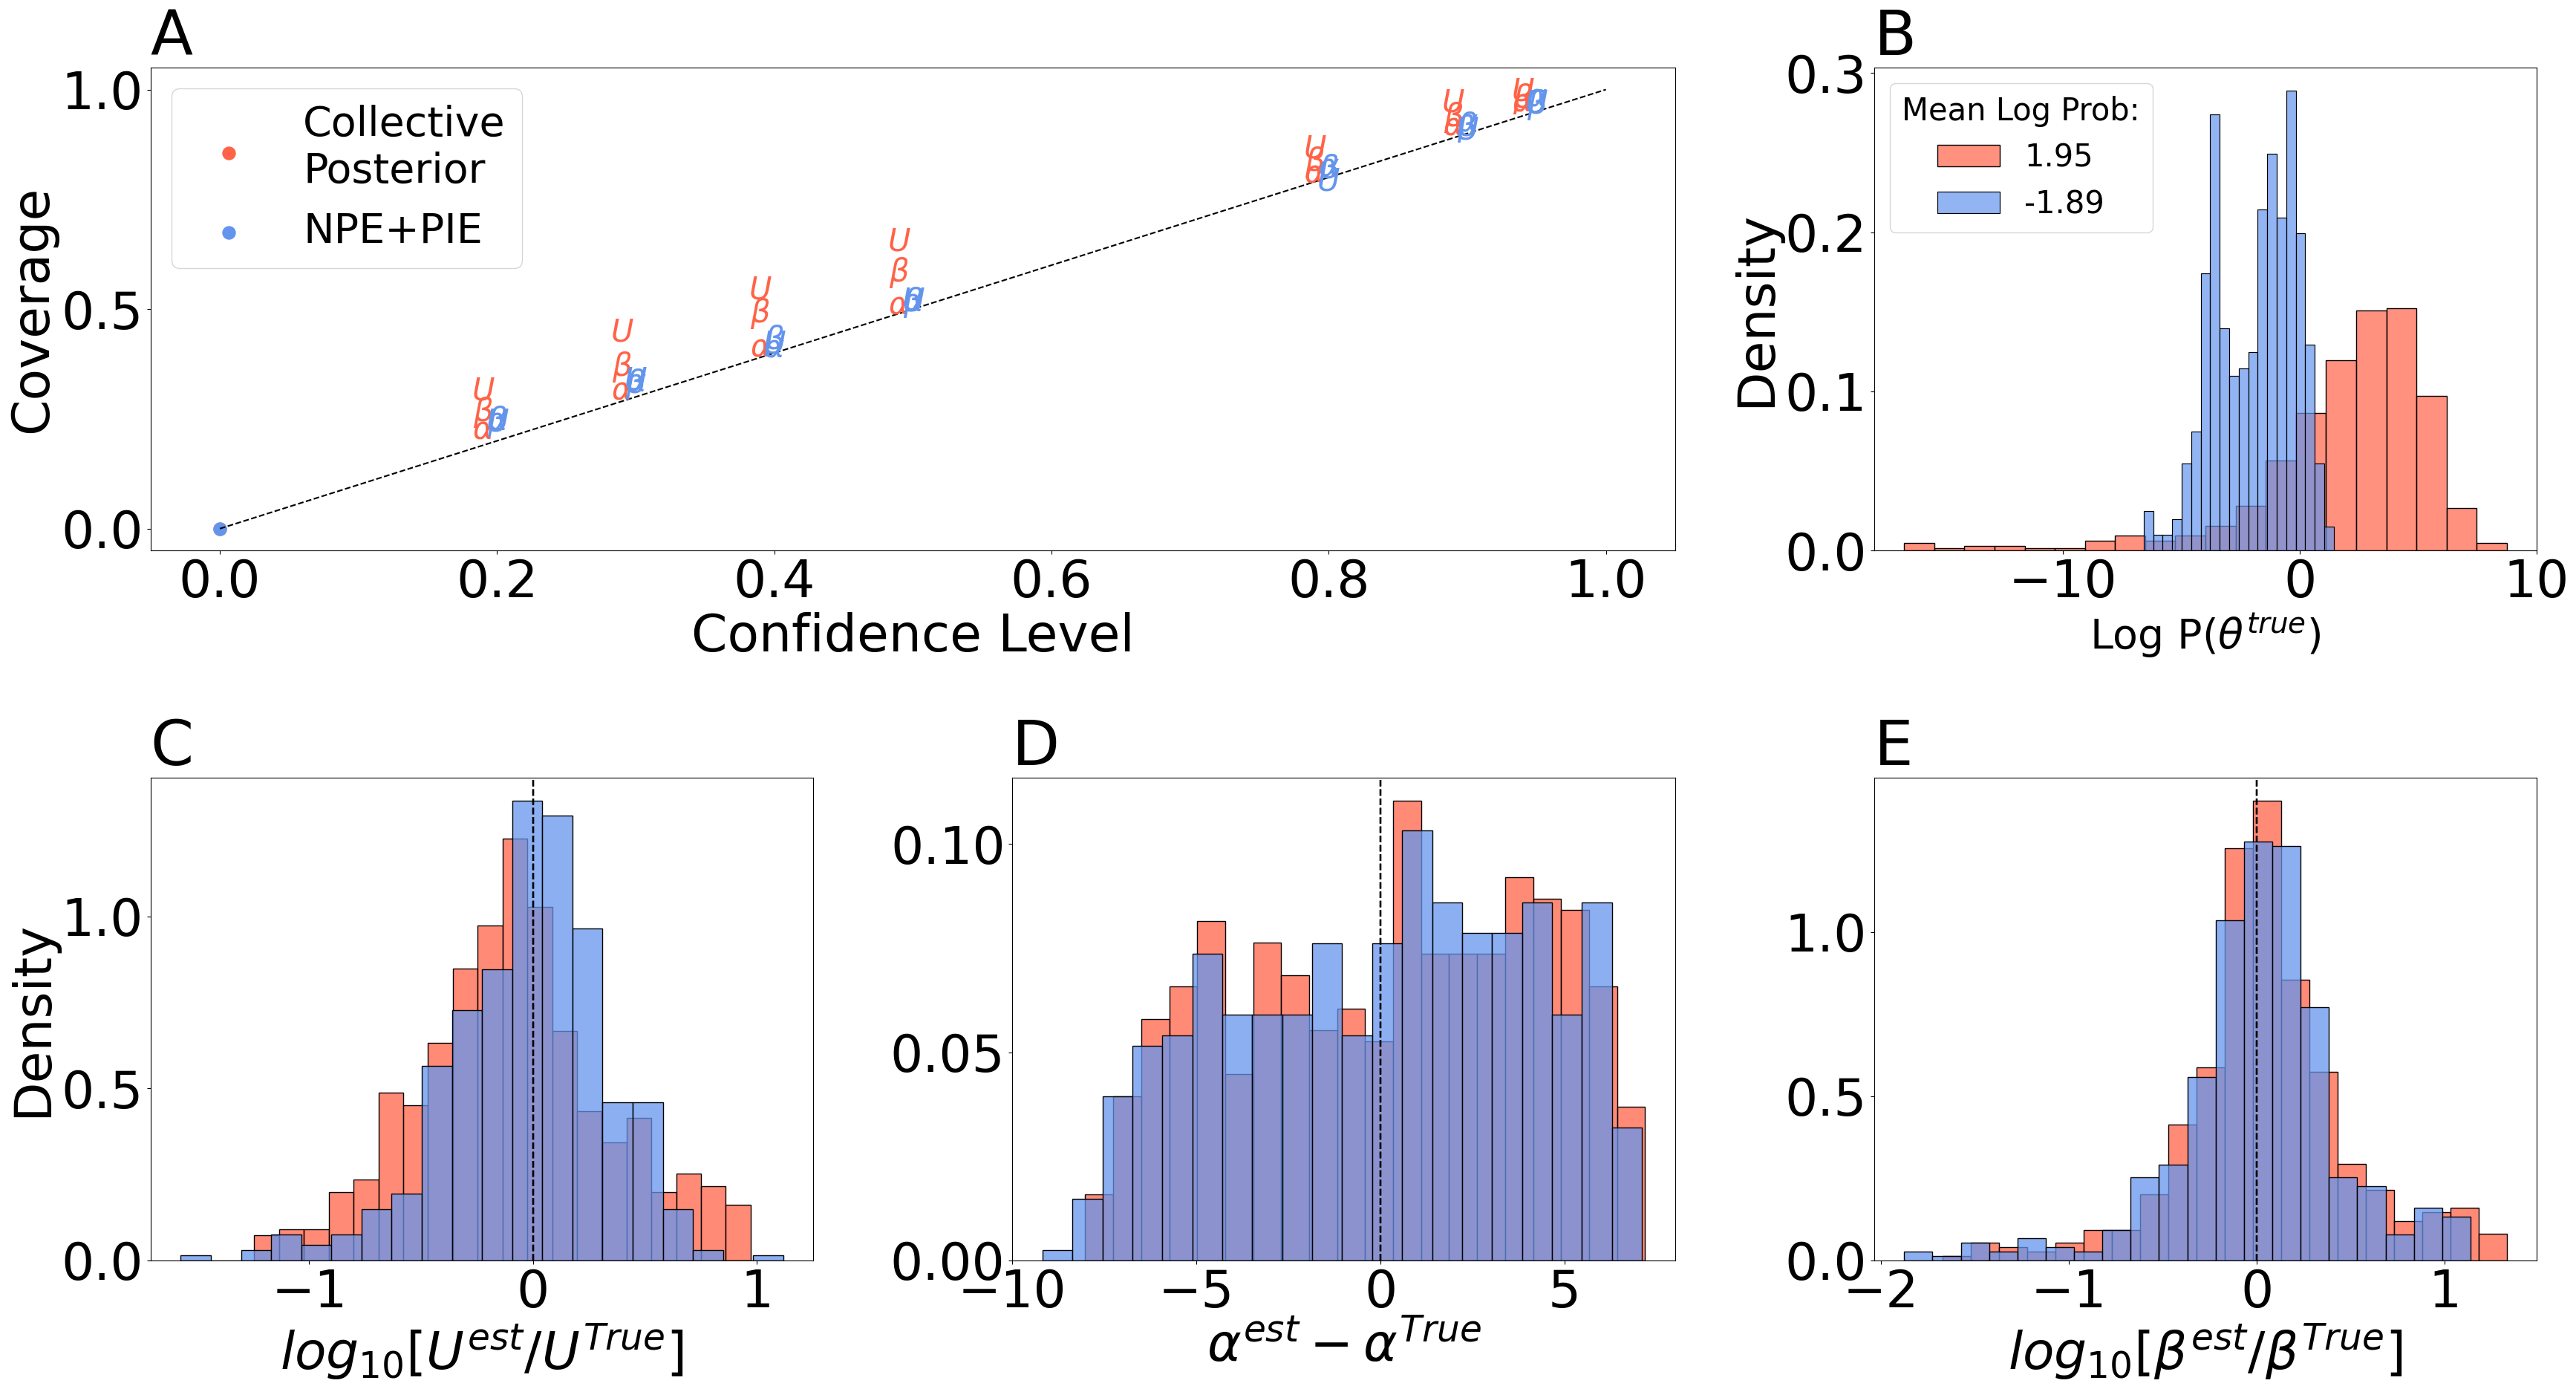

In [22]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=20, label=label, hatch=hatch)
        # kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=False):
    param_names = ['$U$', '$\\alpha$', '$\\beta$']
    adjust=-0.01 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, color=color, fontsize=30, ha='center', va='bottom')
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=400)
    ax.scatter(0,0,s=150, label=label, color=color)
        
def tensor_cdf(tensor):
    """
    Given a 1D torch tensor or numpy array, returns (sorted_values, cdf_values) for plotting.
    """
    if isinstance(tensor, torch.Tensor):
        arr = tensor.detach().cpu().numpy().flatten()
    else:
        arr = np.asarray(tensor).flatten()
    sorted_vals = np.sort(arr)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    return sorted_vals, cdf

def plot_covs_cdf(ax, covs, color, label):
    """
    Plot the CDF of each column in covs (DataFrame or tensor) on the given axis.
    """
    param_names = ['$log U$', '$\\alpha$', '$log \\beta$']
    if hasattr(covs, 'columns'):
        columns = covs.columns
    else:
        columns = range(covs.shape[1])
    for i, p in enumerate(columns):
        vec = covs[p] if hasattr(covs, 'columns') else covs[:,i]
        sorted_vals, cdf = tensor_cdf(vec)
        ax.plot(sorted_vals, cdf, label=param_names[i] if i < len(param_names) else str(p), color=color)
    ax.legend()
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.set_title(label)

def plot_log_probs(ax, log_probs, color, label):
    histplot(log_probs, ax=ax, label=label, color=color, stat='density', bins=20, alpha=0.7)
    ax.legend(title='Mean Log Prob:', fontsize=30, title_fontsize=30, loc='upper left')
    ax.set_xlabel('Log P($\\theta^{true}$)', fontsize=40)
    ax.set_ylabel('Density')


# A - log probabilites
# B - Coverage plots
# C-E - Accuracy plots
mosaic = '''AAB
            CDE
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')

# plot log probs in ax A

log_probs_cp = pd.read_csv('tests/logprobs_GORDO_r.csv', index_col=0, dtype='float').to_numpy().flatten()
plot_log_probs(ax['B'], log_probs_cp, color='tomato', label=round(log_probs_cp.mean(),2))
log_probs_iid = pd.read_csv('tests/logprobs_GORDO_iid_r.csv', index_col=0, dtype='float').to_numpy().flatten()
plot_log_probs(ax['B'], log_probs_iid, color='cornflowerblue', label=round(log_probs_iid.mean(),2))
ax['B'].set_xlabel('Log P($\\theta^{true}$)')
ax['B'].set_ylabel('Density')

# Coverage plots in ax B
ax['A'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_GORDO_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_,label='Collective\nPosterior',color='tomato', cp=True)
covs_iid = pd.read_csv(f'tests/covs_old_GORDO_iid_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)

# Accuracy plots in ax C-E
n_params=3
ax['C'].set_xlabel('$log_{10}[U^{est} / {U^{True}}]$')
ax['D'].set_xlabel('$\\alpha^{est} - {\\alpha^{True}}$')
ax['E'].set_xlabel('$log_{10}[\\beta^{est} / {\\beta^{True}}]$')

axx = [ax['C'], ax['D'], ax['E']]

cp_acc = 'tests/accus_GORDO_r.csv'
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = 'tests/accus_GORDO_iid_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['D'].set_ylabel('')
ax['E'].set_ylabel('')




Text(0, 0.5, '')

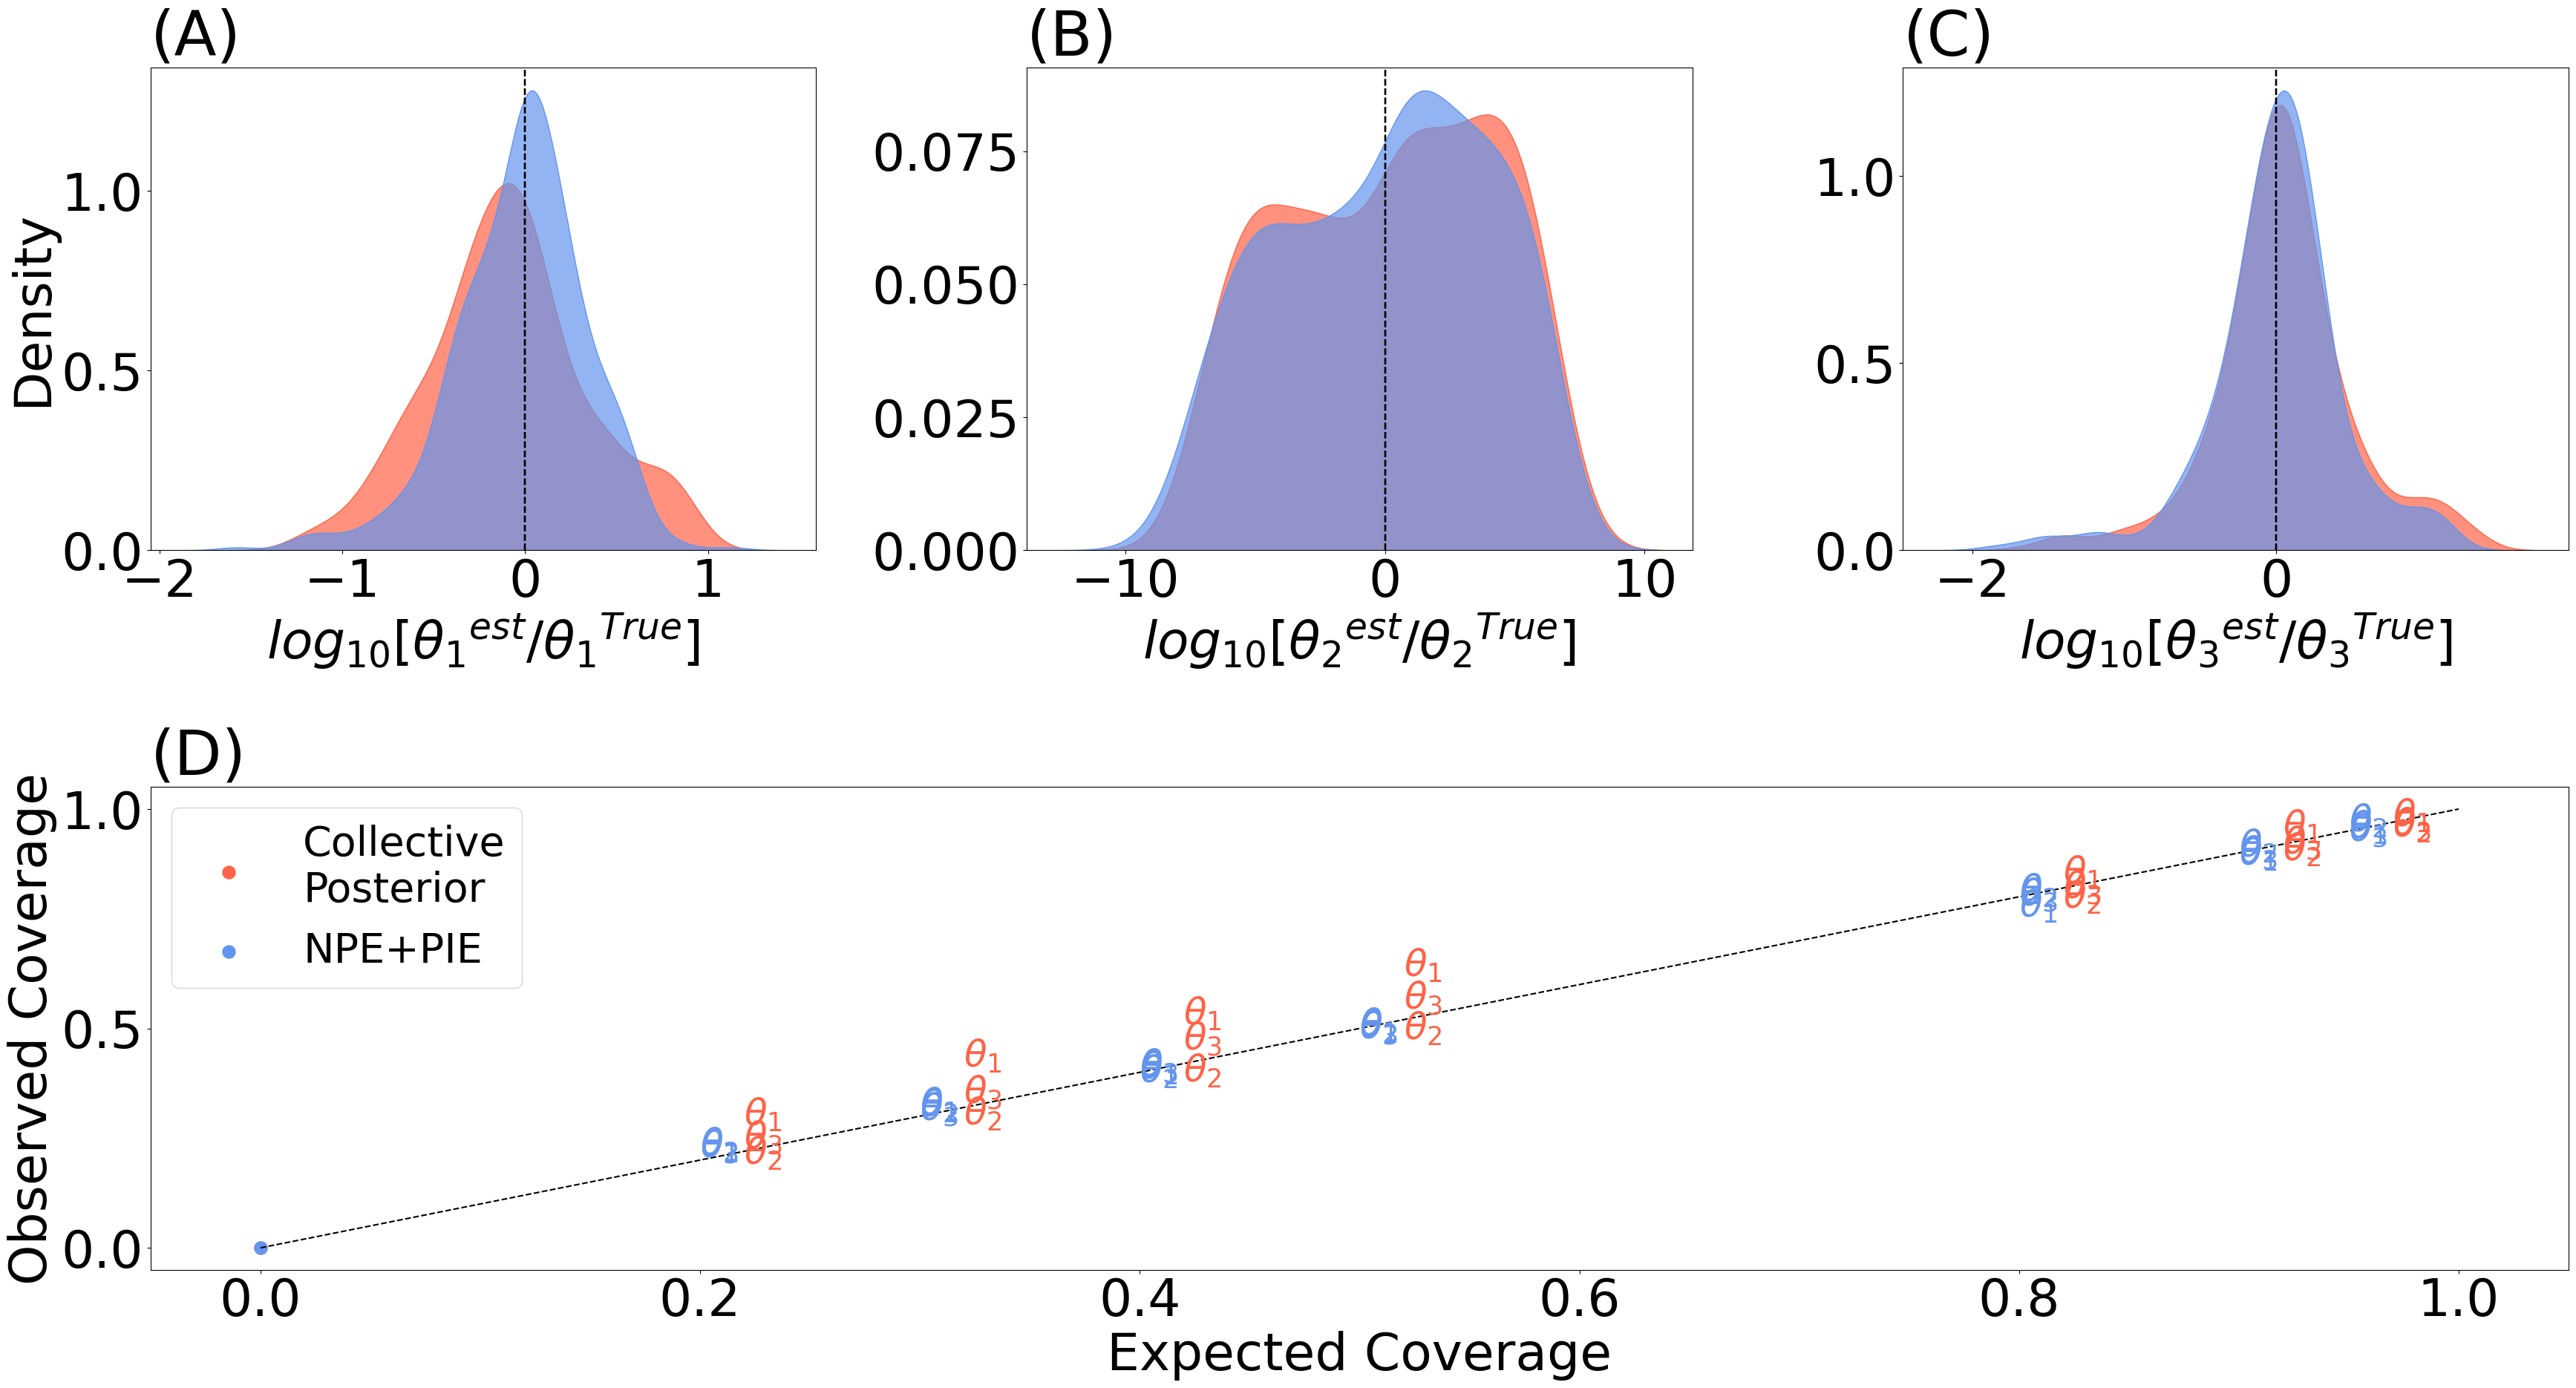

In [ ]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        # histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=10, label=label, hatch=hatch)
        kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=True):
    param_names = ['$θ_1$', '$θ_2$', '$θ_3$']
    adjust=0.02 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=200)
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, fontsize=36, color=color)
    ax.scatter(0,0,s=150, label=label, color=color)
        
        

mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('(A)',loc='left')
ax['B'].set_title('(B)',loc='left')
ax['C'].set_title('(C)',loc='left')
ax['D'].set_title('(D)',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_GORDO_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_,label='Collective\nPosterior',color='tomato')
covs_iid = pd.read_csv(f'tests/covs_old_GORDO_iid_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue', cp=False)
# covs = pd.read_csv(f'tests/covs_old_GORDO_m.csv', index_col=0, dtype='float')
# plot_covs_old(ax=ax['D'], covs=covs,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[{θ_1}^{est} / {{θ_1}^{True}}]$')
ax['B'].set_xlabel('$log_{10}[{θ_2}^{est} / {{θ_2}^{True}}]$')
ax['C'].set_xlabel('$log_{10}[{θ_3}^{est} / {{θ_3}^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_GORDO_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

# cp_acc_m = 'tests/accus_GORDO_m.csv'
# plot_accuracy(cp_acc_m, axx, color='maroon', hatch='///', label='')

iid_acc = 'tests/accus_GORDO_iid_h_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['D'].legend(fontsize=40)
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_GORDO_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

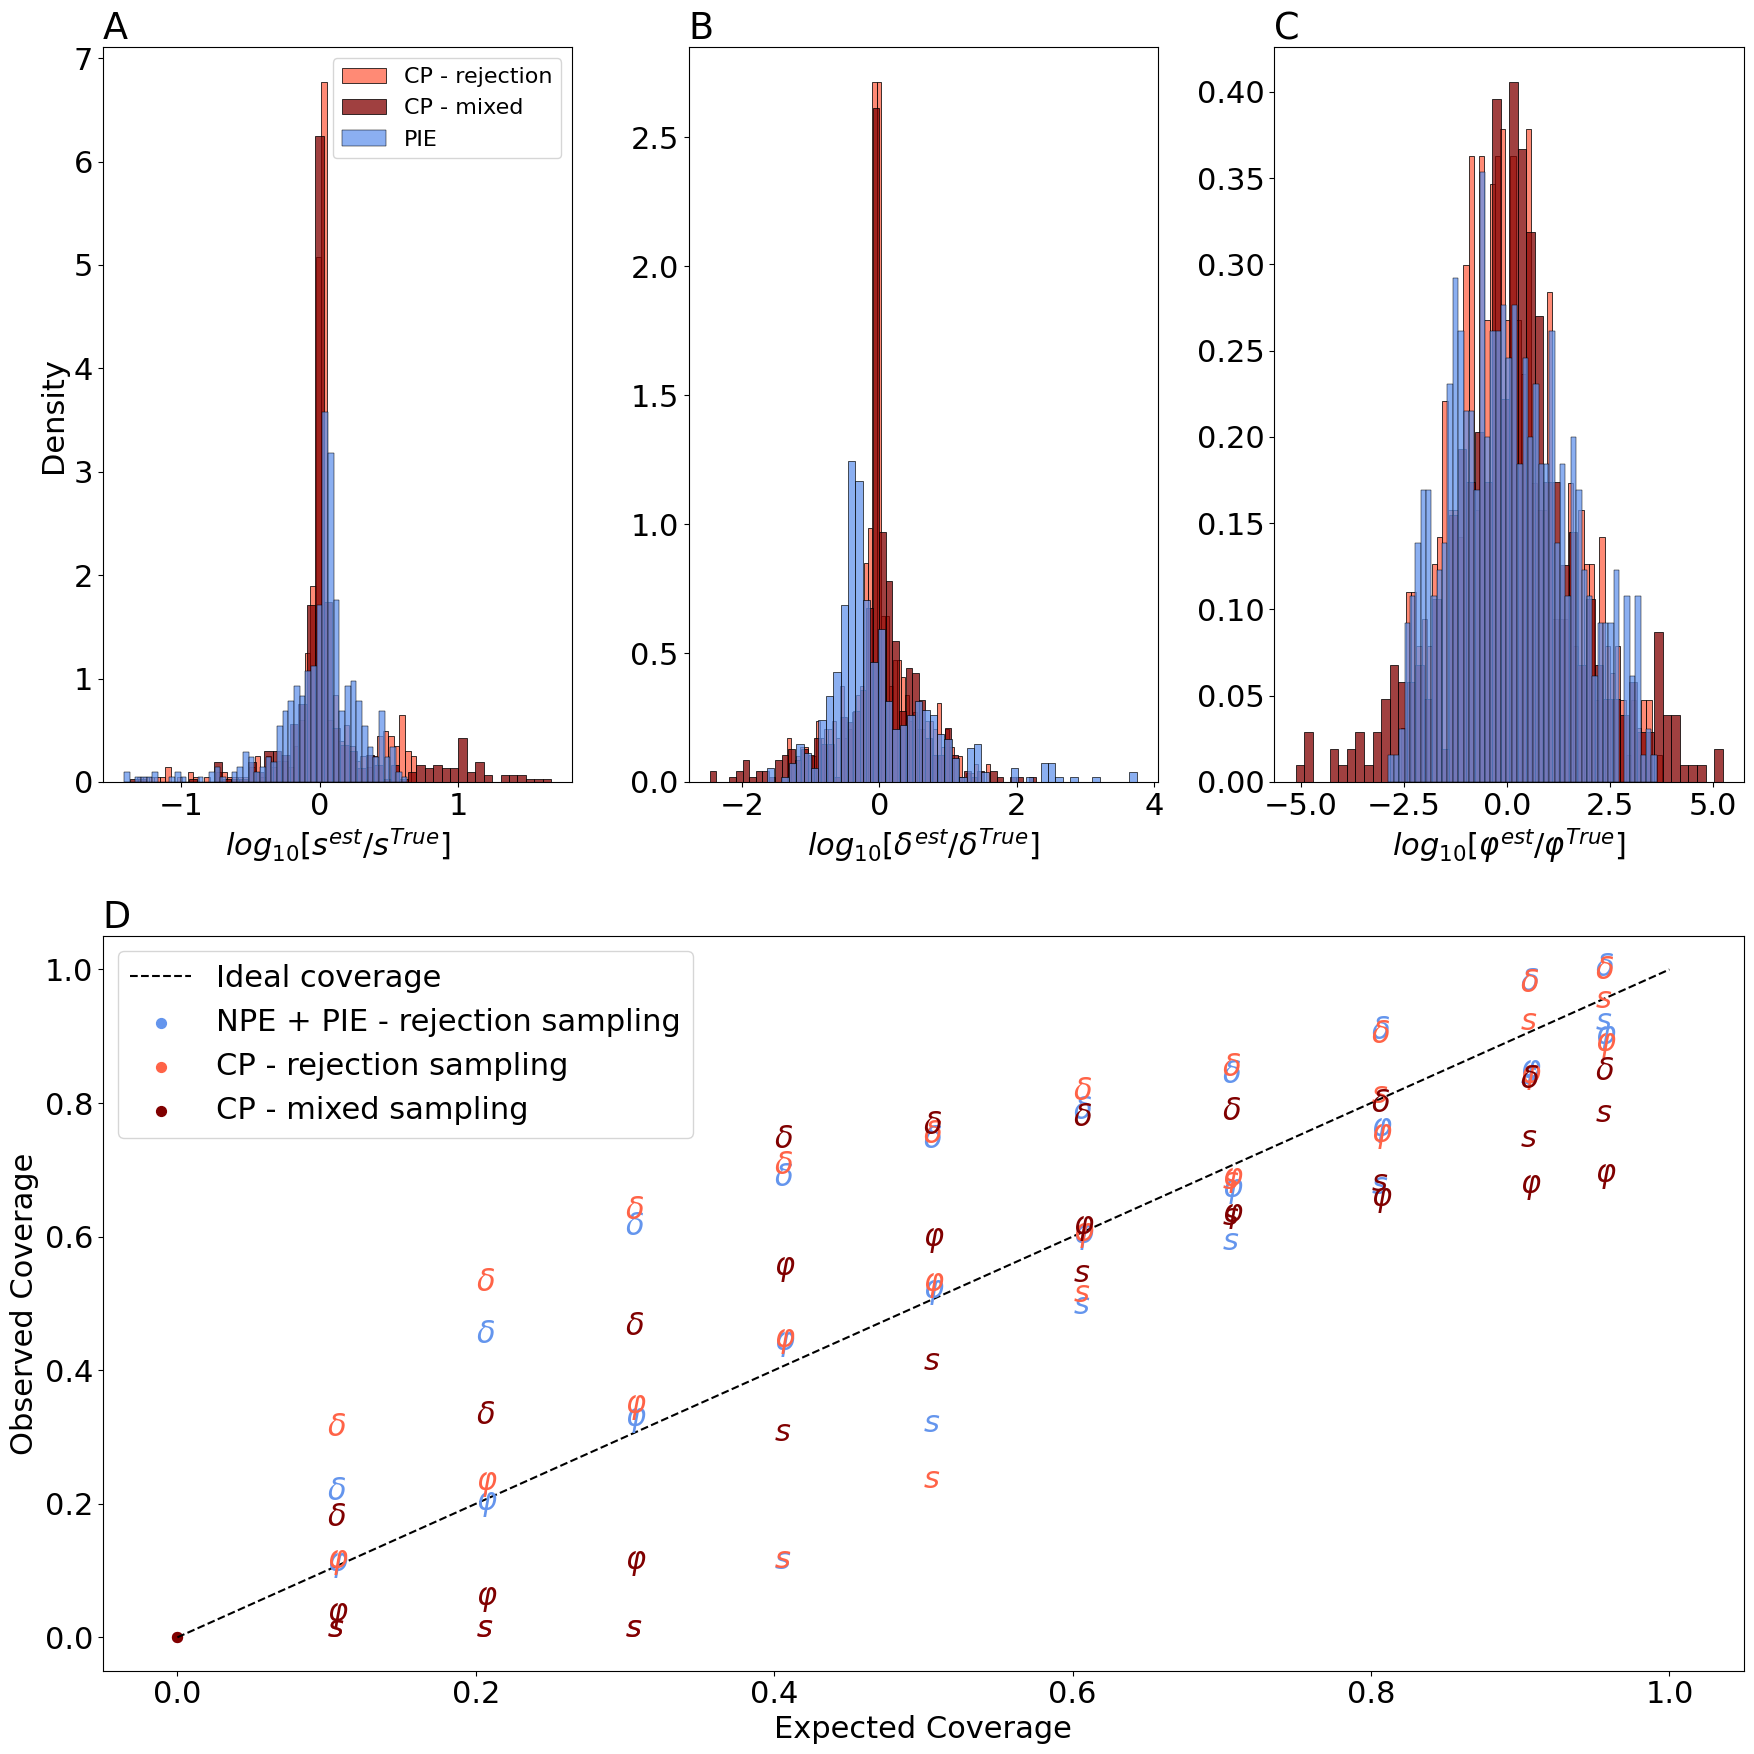

In [ ]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE - rejection sampling',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='CP - rejection sampling',color='tomato')
plot_covs_old(ax=ax['D'], covs=covs_cp_m,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_GORDO_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP - rejection')

cp_m_acc = 'tests/accus_WF_m.csv'
plot_accuracy(cp_m_acc, axx, color='maroon', hatch='', label='CP - mixed')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper right', fontsize=16)
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

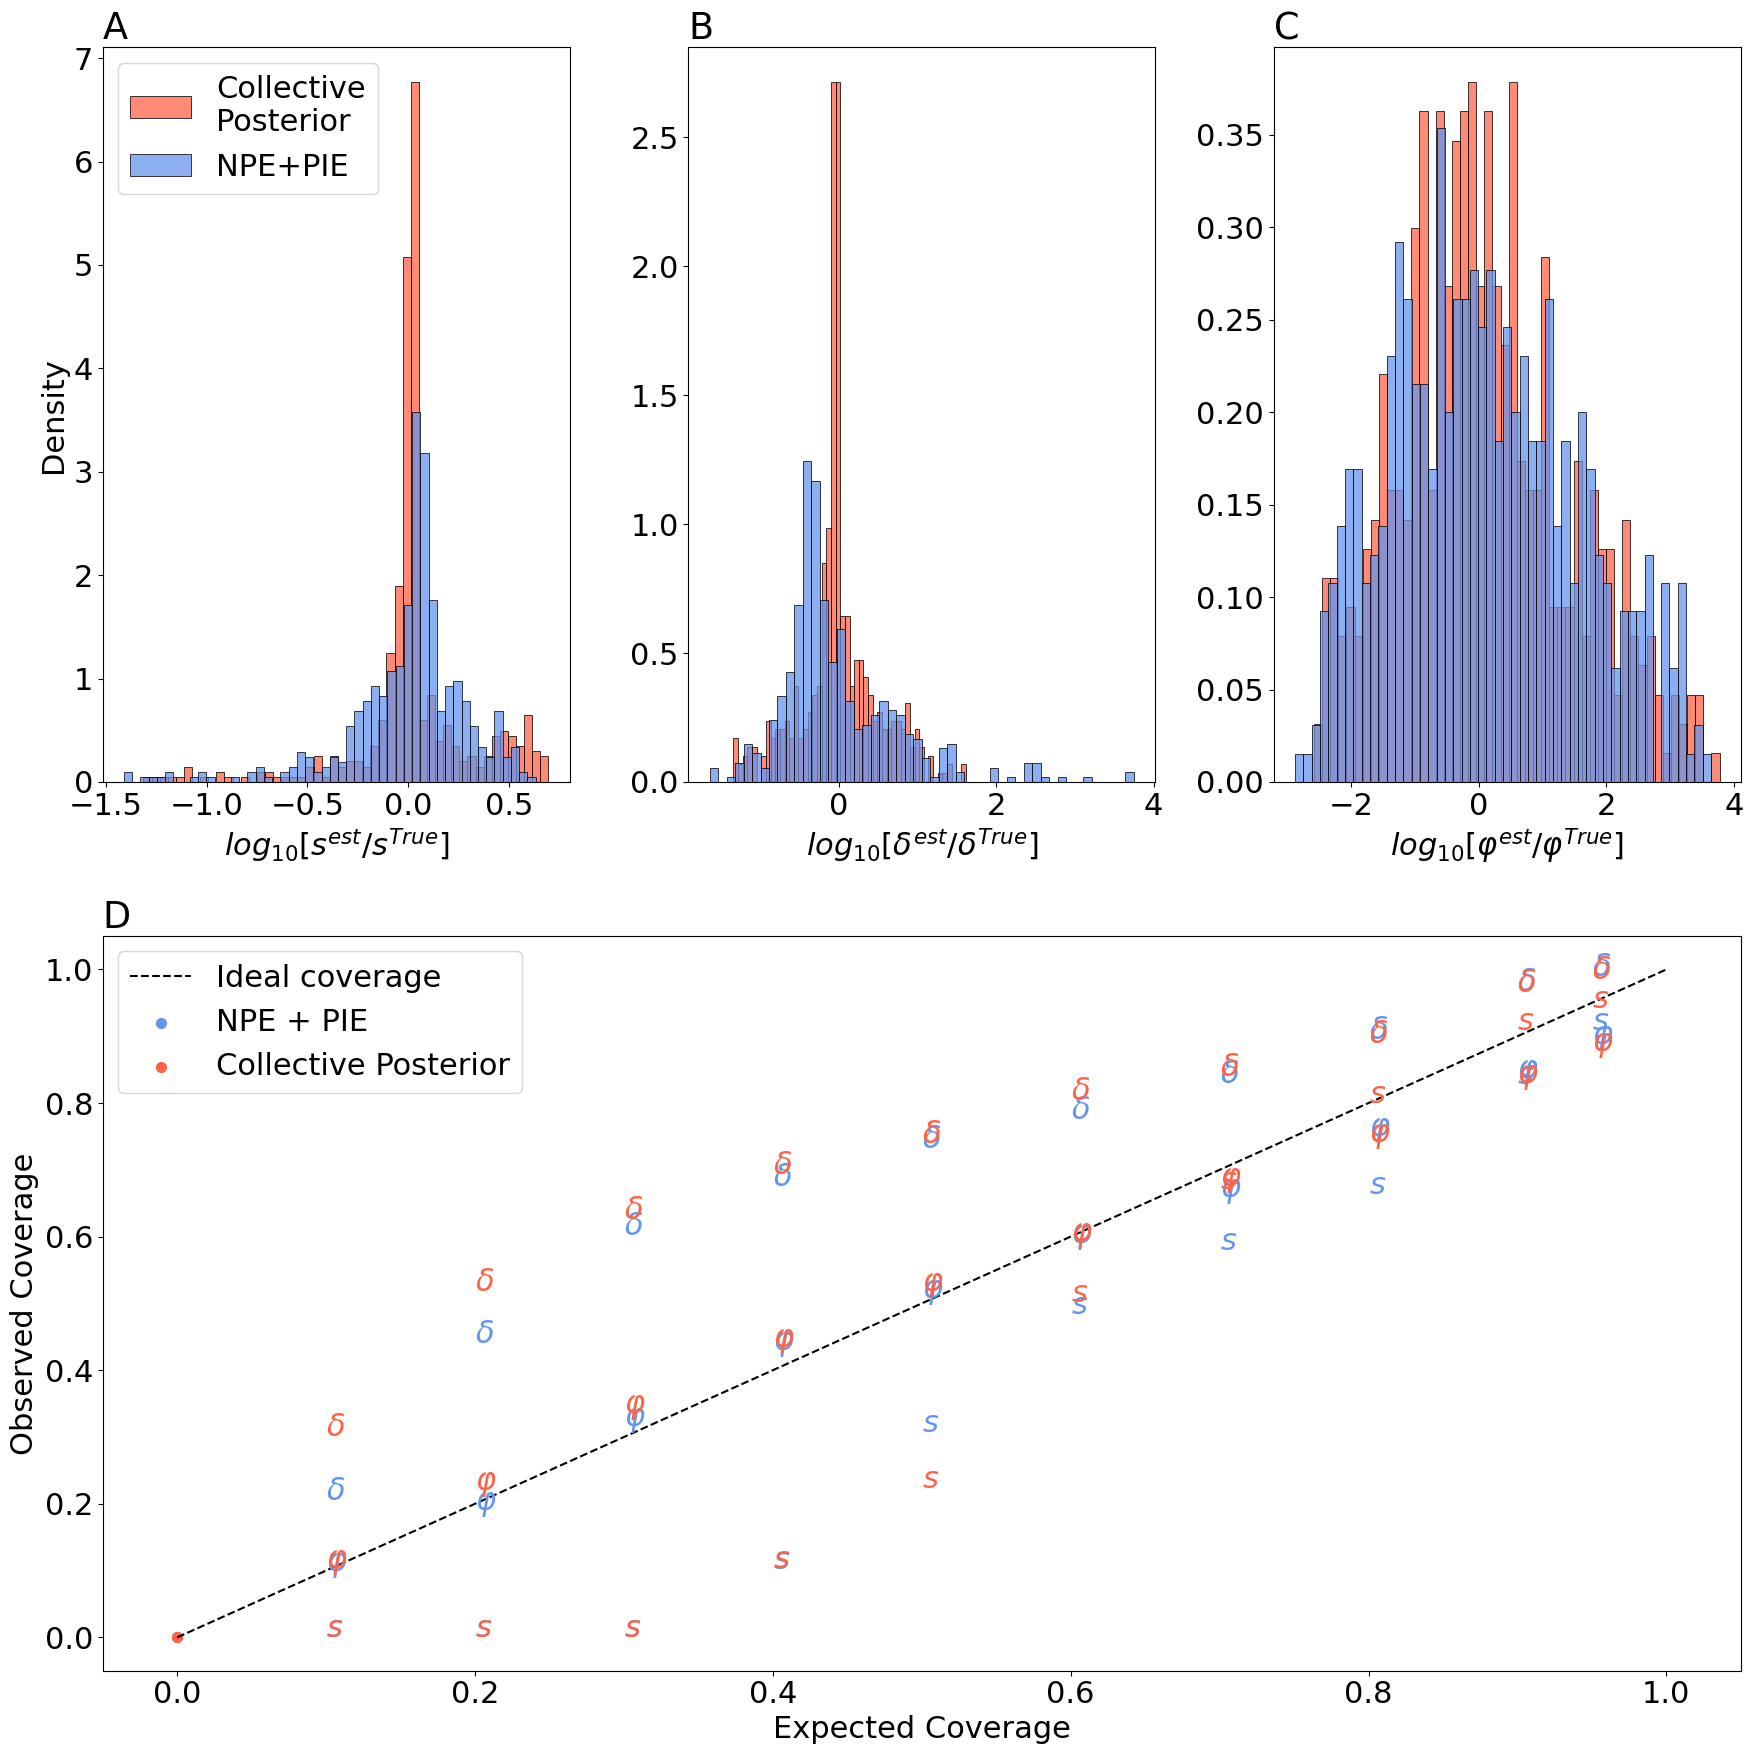

In [15]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='Collective Posterior',color='tomato')


n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['A'].legend()
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



In [29]:
thetas = pd.read_csv('tests/test_thetas.csv', index_col=0)
thetas = torch.from_numpy(np.array(thetas))

cpa = pd.read_csv(cp_acc, index_col=0)
cpa = torch.from_numpy(np.array(cpa))
print(cpa.median(0))
iida = pd.read_csv(iid_acc, index_col=0)
iida = torch.from_numpy(np.array(iida))
print(iida.median(0))

torch.return_types.median(
values=tensor([ 0.0144, -0.0354, -0.0550], dtype=torch.float64),
indices=tensor([119,  11,  95]))
torch.return_types.median(
values=tensor([ 0.0492, -0.2277, -0.0086], dtype=torch.float64),
indices=tensor([ 27,  49, 332]))
